# Maturity Edition: High-Yield Credit Refinancing Analysis

This analysis examines the high-yield credit market through two critical lenses: the **Refinancing Chasm** (yield shock impact) and the **Maturity Wall Proxy** (credit stress timing).

## Core Analysis Framework

### Key Metrics
- **Chart A - Refinancing Chasm**: Current market yields vs. historical average coupons
- **Chart B - Maturity Wall Proxy**: High-yield credit stress measured via OAS spreads
- **Yield Shock**: The margin erosion gap between new and existing financing costs
- **Credit Stress Spikes**: Periods of elevated refinancing difficulty

### Data Sources
- **BAMLH0A0HYM2EY**: High Yield Master II Effective Yield (Current Market Yield)
- **BAMLH0A0HYM2OAS**: High Yield Master II Option-Adjusted Spread (Credit Stress)
- **Proxy Average Coupon**: Static 5.50% representing historical financing costs

---

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas_datareader.data as web
import datetime
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print("📊 Maturity Edition: High-Yield Credit Refinancing Analysis")
print(f"Analysis date: {datetime.datetime.now().strftime('%Y-%m-%d')}")

Libraries imported successfully!
📊 Maturity Edition: High-Yield Credit Refinancing Analysis
Analysis date: 2025-11-24


In [8]:
# --- Configuration ---
print("⚙️  Setting up high-yield credit refinancing analysis...")

# Analysis timeframe
START_DATE = datetime.datetime(2019, 1, 1)  # 7-year lookback for context
END_DATE = datetime.datetime.now()

# High-Yield Credit Data Series (FRED)
CREDIT_SERIES = {
    'BAMLH0A0HYM2EY': 'High Yield Master II Effective Yield',  # Chart A: Current Market Yield
    'BAMLH0A0HYM2OAS': 'High Yield Master II Option-Adjusted Spread'  # Chart B: Credit Stress (OAS)
}

# Analysis Parameters
PROXY_AVERAGE_COUPON = 5.50  # Static line representing historical financing costs (%)

print(f"📅 Analysis Period: {START_DATE.strftime('%Y-%m-%d')} to {END_DATE.strftime('%Y-%m-%d')}")
print("📊 Focus: Refinancing Chasm and Maturity Wall analysis")
print("💾 Data sources: FRED API for High-Yield Credit metrics")
print(f"🎯 Proxy Average Coupon: {PROXY_AVERAGE_COUPON}%")

⚙️  Setting up high-yield credit refinancing analysis...
📅 Analysis Period: 2019-01-01 to 2025-11-24
📊 Focus: Refinancing Chasm and Maturity Wall analysis
💾 Data sources: FRED API for High-Yield Credit metrics
🎯 Proxy Average Coupon: 5.5%


In [13]:
# --- High-Yield Credit Data Fetching ---
print("🚀 Fetching high-yield credit data from FRED...")

try:
    credit_data = {}
    
    for series, description in CREDIT_SERIES.items():
        print(f"   • Fetching {description}...")
        try:
            data = web.DataReader(series, 'fred', start=START_DATE, end=END_DATE)
            credit_data[series] = data[series]
        except Exception as e:
            print(f"     ⚠️  {description} unavailable: {e}")
    
    # Combine all credit data
    credit_df = pd.DataFrame(credit_data)
    
    # Forward fill missing data
    credit_df = credit_df.ffill()
    
    # Clean data
    credit_df = credit_df.dropna()
    
    print(f"✅ High-yield credit data loaded successfully!")
    print(f"   • Date range: {credit_df.index[0].strftime('%Y-%m-%d')} to {credit_df.index[-1].strftime('%Y-%m-%d')}")
    print(f"   • Available series: {len(credit_df.columns)}")
    print(f"   • Total observations: {len(credit_df)}")
    
    # Current values for summary
    current_yield = credit_df['BAMLH0A0HYM2EY'].iloc[-1]
    current_oas = credit_df['BAMLH0A0HYM2OAS'].iloc[-1]
    yield_shock = current_yield - PROXY_AVERAGE_COUPON
    
    print(f"\n📊 CURRENT REFINANCING METRICS:")
    print(f"   • Current Market Yield: {current_yield:.2f}%")
    print(f"   • Proxy Average Coupon: {PROXY_AVERAGE_COUPON:.2f}%")
    print(f"   • Yield Shock (Refinancing Gap): {yield_shock:+.2f}%")
    print(f"   • Current OAS Spread: {current_oas:.0f} bps")
    
except Exception as e:
    print(f"❌ Error fetching credit data: {e}")
    print("⚠️  Creating sample credit data for demonstration...")
    
    # Sample credit data - Full 7-year range
    dates = pd.date_range(start=START_DATE, end=END_DATE, freq='D')
    credit_df = pd.DataFrame(index=dates)
    
    # Generate sample high-yield credit data
    base_yield = 6.5
    base_oas = 400
    
    credit_df['BAMLH0A0HYM2EY'] = base_yield + np.cumsum(np.random.normal(0, 0.02, len(dates)))
    credit_df['BAMLH0A0HYM2OAS'] = base_oas + np.cumsum(np.random.normal(0, 5, len(dates)))
    
    # Keep realistic ranges
    credit_df['BAMLH0A0HYM2EY'] = np.clip(credit_df['BAMLH0A0HYM2EY'], 4, 15)
    credit_df['BAMLH0A0HYM2OAS'] = np.clip(credit_df['BAMLH0A0HYM2OAS'], 200, 1000)
    
    credit_df = credit_df.ffill().dropna()

🚀 Fetching high-yield credit data from FRED...
   • Fetching High Yield Master II Effective Yield...
   • Fetching High Yield Master II Option-Adjusted Spread...
   • Fetching High Yield Master II Option-Adjusted Spread...
     ⚠️  High Yield Master II Option-Adjusted Spread unavailable: Unable to read URL: https://fred.stlouisfed.org/graph/fredgraph.csv?id=BAMLH0A0HYM2OAS
Response Text:
b'<!DOCTYPE html>\r\n<html lang="en">\r\n<head>\r\n    <meta charset="utf-8">\r\n    <meta http-equiv="X-UA-Compatible" content="IE=edge">\r\n    <meta name="viewport" content="width=device-width, initial-scale=1">\r\n    <title>Error - St. Louis Fed</title>\r\n    <meta name="description" content="">\r\n    <meta name="keywords" content="">    \r\n    <link rel="stylesheet" type="text/css" href="/assets/bootstrap/dist/css/bootstrap.min.css">\r\n    <link rel="stylesheet" type="text/css" href="/css/home.min.css?1553087253">\r\n    <link rel="stylesheet" type="text/css" href="/assets/fontawesome-free/cs

📊 Creating Chart A: Refinancing Chasm...


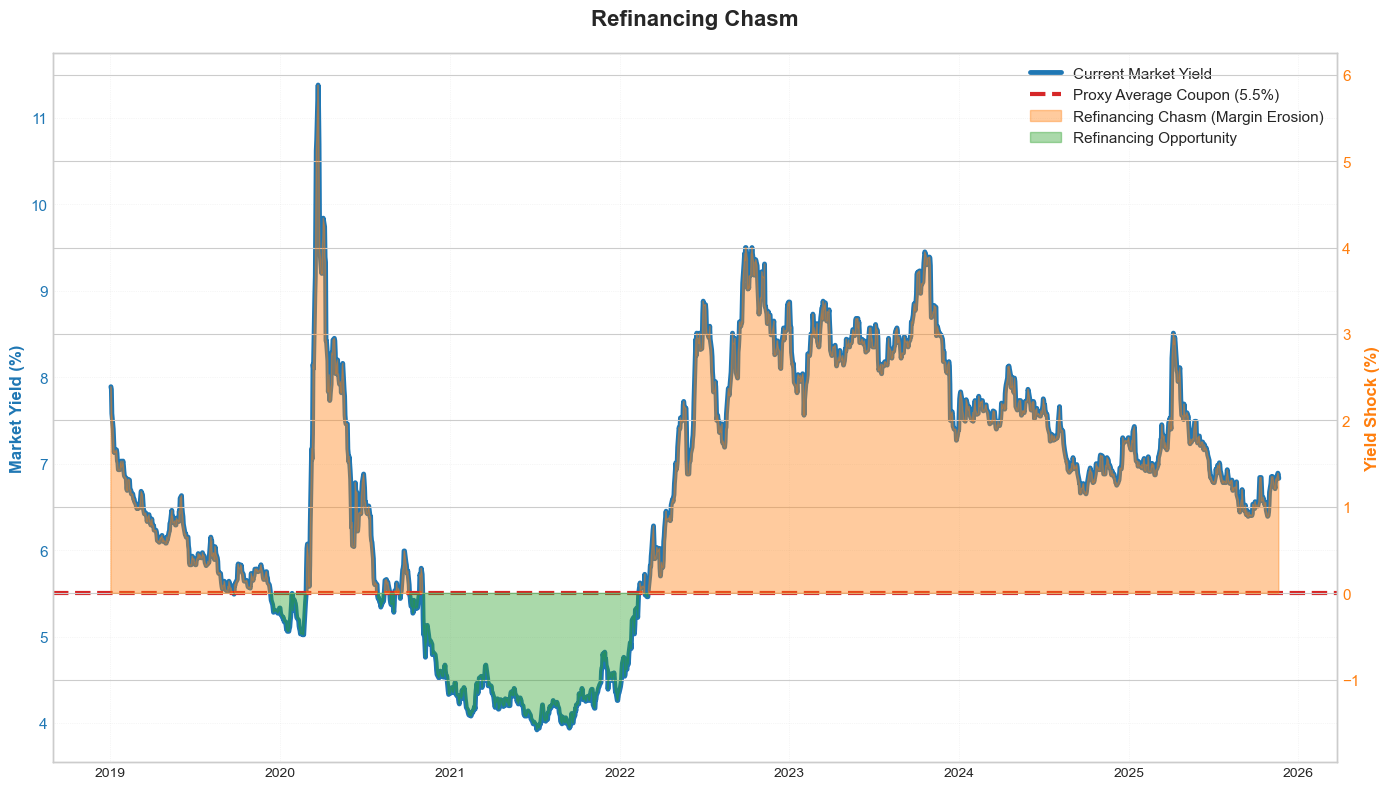


✅ REFINANCING CHASM ANALYSIS:
   • Current Market Yield: 6.83%
   • Proxy Average Coupon: 5.50%
   • Current Yield Shock: +1.33% (CHASM)
   • Refinancing Impact: Margin Erosion


In [ ]:
# --- CHART A: REFINANCING CHASM ---
print("📊 Creating Chart A: Refinancing Chasm...")

# Import required plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set up professional chart styling
sns.set_style("whitegrid")
plt.style.use('seaborn-v0_8-whitegrid')

# Create figure with dual y-axis
fig, ax1 = plt.subplots(figsize=(14, 8))

# Primary Y-axis: Current Market Yield - Sharp Newsletter Colors
color_market = '#1f77b4'  # Bright blue
line1 = ax1.plot(credit_df.index, credit_df['BAMLH0A0HYM2EY'], 
                 color=color_market, linewidth=3.5, alpha=1.0, 
                 label='Current Market Yield')

ax1.set_title('Refinancing Chasm', 
              fontsize=16, fontweight='bold', pad=20)
ax1.set_ylabel('Market Yield (%)', color=color_market, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_market, labelsize=11)

# Add static Proxy Average Coupon line - Sharp red
color_proxy = '#d62728'  # Bright red
ax1.axhline(y=PROXY_AVERAGE_COUPON, color=color_proxy, linestyle='--', 
            linewidth=3, alpha=1.0, label=f'Proxy Average Coupon ({PROXY_AVERAGE_COUPON}%)')

# Secondary Y-axis for the Gap (Yield Shock)
ax2 = ax1.twinx()
yield_shock_series = credit_df['BAMLH0A0HYM2EY'] - PROXY_AVERAGE_COUPON
color_shock = '#ff7f0e'  # Bright orange

# Fill area to show the refinancing chasm - More vibrant colors
ax2.fill_between(credit_df.index, 0, yield_shock_series, 
                 where=(yield_shock_series > 0), alpha=0.4, color=color_shock, 
                 label='Refinancing Chasm (Margin Erosion)')
ax2.fill_between(credit_df.index, 0, yield_shock_series, 
                 where=(yield_shock_series <= 0), alpha=0.4, color='#2ca02c', 
                 label='Refinancing Opportunity')

ax2.set_ylabel('Yield Shock (%)', color=color_shock, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_shock, labelsize=11)

# Professional date formatting
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter

ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_minor_locator(mdates.MonthLocator(interval=6))
ax1.xaxis.set_major_formatter(DateFormatter('%Y'))
ax1.tick_params(axis='x', labelsize=10)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, 
           loc='upper right', fontsize=11, framealpha=0.9)

# Make grid lines dotted and very faint
ax1.grid(True, alpha=0.15, linewidth=0.5, linestyle=':', color='gray')

plt.tight_layout()
plt.show()

# Print current refinancing metrics
current_yield = credit_df['BAMLH0A0HYM2EY'].iloc[-1]
current_shock = current_yield - PROXY_AVERAGE_COUPON

print(f"\n✅ REFINANCING CHASM ANALYSIS:")
print(f"   • Current Market Yield: {current_yield:.2f}%")
print(f"   • Proxy Average Coupon: {PROXY_AVERAGE_COUPON:.2f}%")
print(f"   • Current Yield Shock: {current_shock:+.2f}% ({'CHASM' if current_shock > 0 else 'OPPORTUNITY'})")
print(f"   • Refinancing Impact: {'Margin Erosion' if current_shock > 0 else 'Cost Savings'}")

📊 Creating Chart B: Maturity Wall Proxy...


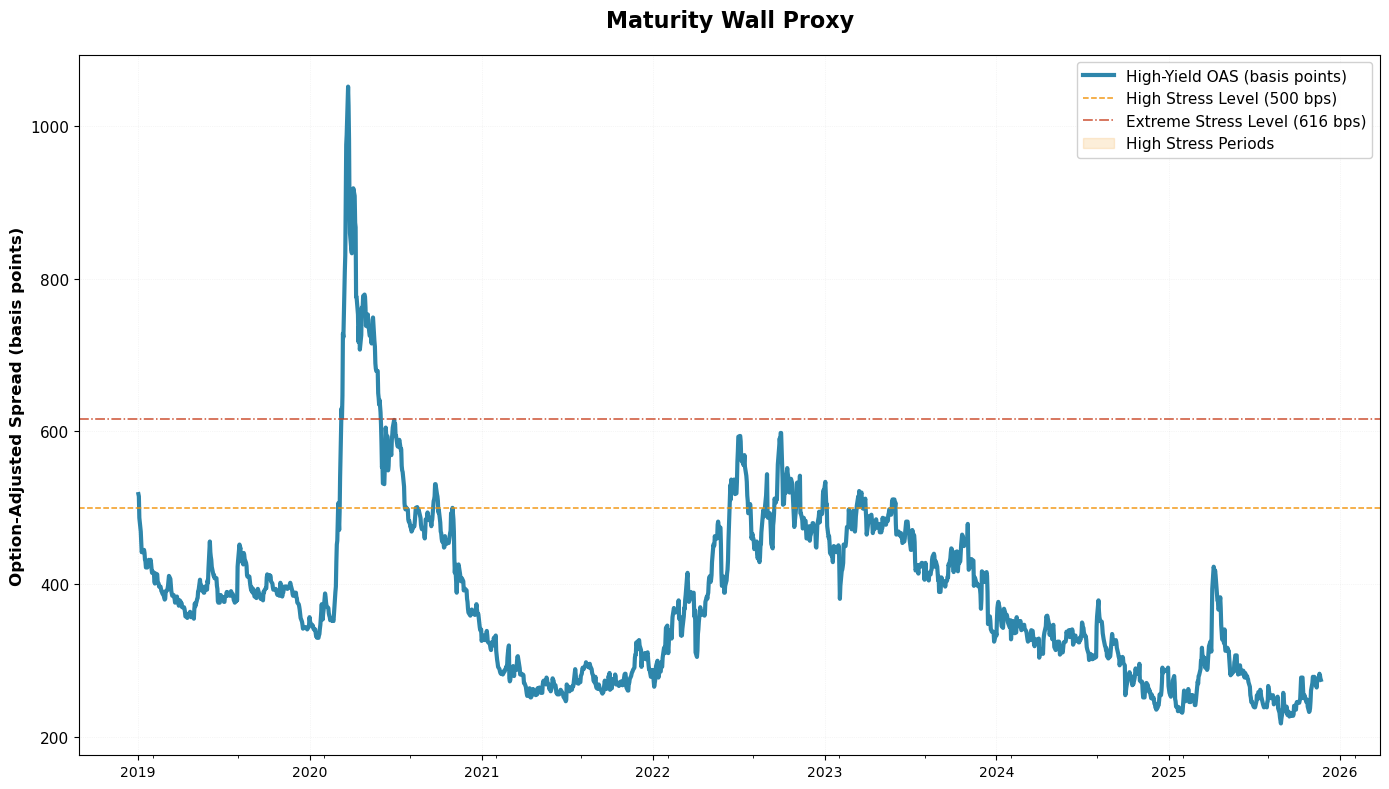


✅ MATURITY WALL PROXY ANALYSIS:
   • Current OAS Spread: 275 bps
   • Historical Mean: 384 bps
   • High Stress Threshold: 500 bps
   • Extreme Stress Threshold: 616 bps
   • Current Stress Level: NORMAL
   • Refinancing Difficulty: Moderate


In [19]:
# --- CHART B: MATURITY WALL PROXY ---
print("📊 Creating Chart B: Maturity Wall Proxy...")

# Import required plotting libraries
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter

# Create single-axis chart for OAS tracking
fig, ax = plt.subplots(figsize=(14, 8))

# Plot High-Yield OAS over time - Less red, more professional
color_oas = '#2E86AB'  # Professional blue
ax.plot(credit_df.index, credit_df['BAMLH0A0HYM2OAS'], 
        color=color_oas, linewidth=3, alpha=1.0, 
        label='High-Yield OAS (basis points)')

ax.set_title('Maturity Wall Proxy', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Option-Adjusted Spread (basis points)', fontsize=12, fontweight='bold')
ax.tick_params(axis='y', labelsize=11)
ax.grid(True, alpha=0.15, linewidth=0.5, linestyle=':', color='gray')

# Add stress level indicators with distinct colors
oas_mean = credit_df['BAMLH0A0HYM2OAS'].mean()
oas_std = credit_df['BAMLH0A0HYM2OAS'].std()

# High stress threshold (mean + 1 std dev) - Orange
high_stress = oas_mean + oas_std
ax.axhline(y=high_stress, color='#F18F01', linestyle='--', alpha=0.9, linewidth=1.1,
           label=f'High Stress Level ({high_stress:.0f} bps)')

# Extreme stress threshold (mean + 2 std dev) - Deep red
extreme_stress = oas_mean + 2*oas_std
ax.axhline(y=extreme_stress, color='#C73E1D', linestyle='-.', alpha=0.9, linewidth=1.1,
           label=f'Extreme Stress Level ({extreme_stress:.0f} bps)')

# Highlight stress periods with background shading - Light orange
stress_periods = credit_df['BAMLH0A0HYM2OAS'] > high_stress
ax.fill_between(credit_df.index, ax.get_ylim()[0], ax.get_ylim()[1], 
                where=stress_periods, alpha=0.15, color='#F18F01', 
                transform=ax.get_xaxis_transform(), 
                label='High Stress Periods')

# Professional date formatting
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(DateFormatter('%Y'))
ax.tick_params(axis='x', labelsize=10)

# Legend - moved to upper right
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.show()

# Print maturity wall analysis
current_oas = credit_df['BAMLH0A0HYM2OAS'].iloc[-1]
stress_level = "EXTREME" if current_oas > extreme_stress else "HIGH" if current_oas > high_stress else "NORMAL"

print(f"\n✅ MATURITY WALL PROXY ANALYSIS:")
print(f"   • Current OAS Spread: {current_oas:.0f} bps")
print(f"   • Historical Mean: {oas_mean:.0f} bps")
print(f"   • High Stress Threshold: {high_stress:.0f} bps")
print(f"   • Extreme Stress Threshold: {extreme_stress:.0f} bps")
print(f"   • Current Stress Level: {stress_level}")
print(f"   • Refinancing Difficulty: {'Very High' if stress_level == 'EXTREME' else 'High' if stress_level == 'HIGH' else 'Moderate'}")